# Deutsche Bank AG — Python-Based Equity Valuation & Scenario Analysis

**Method:** Excess Return / Residual Income Model
**Author:** Chanakya Jamalla
**Data source:** Deutsche Bank FY2025 Annual Report & Q4/FY2025 earnings release (db.com / investor-relations.db.com)

---

Deutsche Bank is a bank, so a standard FCFF/WACC DCF is a poor fit here — capital structure (deposits, leverage) is core to a bank's business model rather than a financing choice, and "free cash flow to the firm" isn't a meaningful concept for a lender.

Instead, this notebook values DB directly from its **equity**, using the **excess return (residual income) model** — the standard framework used by bank equity research analysts. The intuition is simple: a bank only creates shareholder value when it earns a **Return on Equity (ROE) above its Cost of Equity (Ke)**.

$$ \text{Value of Equity} = \text{Book Value}_0 + \sum_{t=1}^{n} \frac{RI_t}{(1+K_e)^t} + \frac{TV_n}{(1+K_e)^n} $$

$$ RI_t = \text{Net Income}_t - K_e \times \text{Book Value}_{t-1} = \text{Book Value}_{t-1} \times (ROE_t - K_e) $$


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.data import DBFinancials, book_value_per_share
from src.model import cost_of_equity_capm, run_residual_income_model, sensitivity_table
from src.scenarios import BASE_CASE, BULL_CASE, BEAR_CASE, ALL_SCENARIOS

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Inputs — sourced from Deutsche Bank's FY2025 disclosures

In [2]:
fin = DBFinancials()

print(f"Total equity (FY2025):        EUR {fin.total_equity_eur_bn:.1f}bn")
print(f"Shares outstanding:            {fin.shares_outstanding_bn:.2f}bn")
print(f"Book value per share:          EUR {book_value_per_share(fin):.2f}")
print(f"FY2025 net profit:             EUR {fin.net_profit_eur_bn:.1f}bn")
print(f"FY2025 post-tax RoE:           {fin.post_tax_roe:.1%}")
print(f"FY2025 post-tax RoTE:          {fin.post_tax_rote:.1%}")
print(f"CET1 ratio:                    {fin.cet1_ratio:.1%}")


Total equity (FY2025):        EUR 80.2bn
Shares outstanding:            1.90bn
Book value per share:          EUR 42.21
FY2025 net profit:             EUR 7.1bn
FY2025 post-tax RoE:           9.3%
FY2025 post-tax RoTE:          10.3%
CET1 ratio:                    14.2%


## 2. Cost of Equity (CAPM)

Using a German 10Y Bund yield as the risk-free rate, an illustrative eurozone equity risk premium, and a beta reflecting DB's investment-bank-heavy revenue mix. **These are assumptions — adjust to your own view.**

In [3]:
risk_free_rate = 0.025
beta = 1.25
equity_risk_premium = 0.055

ke = cost_of_equity_capm(risk_free_rate, beta, equity_risk_premium)
print(f"Cost of Equity (Ke): {ke:.2%}")


Cost of Equity (Ke): 9.38%


## 3. Scenario Assumptions

Three 5-year (FY2026F-FY2030F) ROE paths, anchored to DB's own disclosed results and targets (FY2025 RoTE 10.3%; management's stated ambition of RoTE >13% by 2028).

In [4]:
scenario_table = pd.DataFrame({
    s.name: s.roe_path for s in ALL_SCENARIOS
}, index=[f"Year {i+1}" for i in range(5)]).T
scenario_table.columns.name = "ROE forecast"
scenario_table


ROE forecast,Year 1,Year 2,Year 3,Year 4,Year 5
Base Case,0.10,0.10,0.10,0.11,0.11
Bull Case,0.10,0.11,0.12,0.13,0.13
Bear Case,0.09,0.09,0.09,0.09,0.09


## 4. Run the Valuation

In [5]:
results = {}
for scenario in ALL_SCENARIOS:
    result = run_residual_income_model(
        book_value_0_eur_bn=fin.total_equity_eur_bn,
        cost_of_equity=ke,
        scenario=scenario,
        shares_outstanding_bn=fin.shares_outstanding_bn,
    )
    results[scenario.name] = result

summary = pd.DataFrame([
    {
        "Scenario": name,
        "Fair Value / Share (EUR)": r["fair_value_per_share_eur"],
        "Value of Equity (EUR bn)": r["value_of_equity_eur_bn"],
        "Upside vs Market Price": (r["fair_value_per_share_eur"] / fin.share_price_eur) - 1,
    }
    for name, r in results.items()
])
summary


,Scenario,Fair Value / Share (EUR),Value of Equity (EUR bn),Upside vs Market Price
0,Base Case,52.82,100.36,0.65
1,Bull Case,64.63,122.79,1.02
2,Bear Case,39.41,74.87,0.23


## 5. Visualize - Scenario Comparison

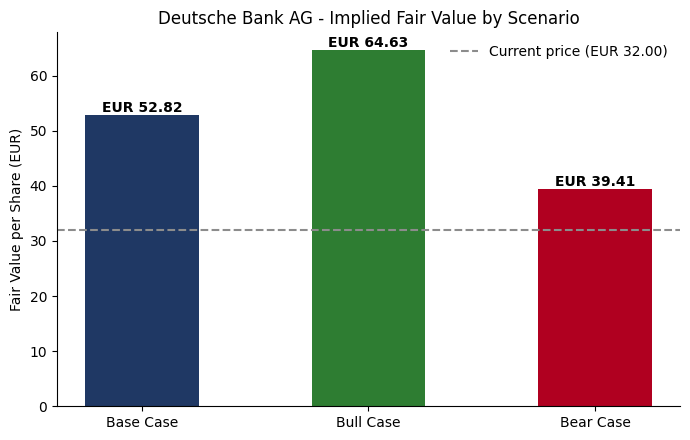

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(results.keys())
values = [results[n]["fair_value_per_share_eur"] for n in names]
bar_colors = {"Bear Case": "#B00020", "Base Case": "#1F3864", "Bull Case": "#2E7D32"}
ax.bar(names, values, color=[bar_colors[n] for n in names], width=0.5)
ax.axhline(fin.share_price_eur, color="#8C8C8C", linestyle="--", label=f"Current price (EUR {fin.share_price_eur:.2f})")
for i, v in enumerate(values):
    ax.text(i, v + 0.5, f"EUR {v:.2f}", ha="center", fontweight="bold")
ax.set_ylabel("Fair Value per Share (EUR)")
ax.set_title("Deutsche Bank AG - Implied Fair Value by Scenario")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Sensitivity - Cost of Equity x Terminal Growth (Base Case)

In [7]:
ke_range = [ke - 0.01, ke - 0.005, ke, ke + 0.005, ke + 0.01]
g_range = [0.010, 0.015, 0.020, 0.025, 0.030]

sens_df = sensitivity_table(
    book_value_0_eur_bn=fin.total_equity_eur_bn,
    scenario=BASE_CASE,
    shares_outstanding_bn=fin.shares_outstanding_bn,
    ke_range=ke_range,
    g_range=g_range,
)
sens_df.style.background_gradient(cmap="RdYlGn", axis=None).format("{:.2f}")


Terminal Growth,1.0%,1.5%,2.0%,2.5%,3.0%
Cost of Equity,,,,,
8.4%,60.03,61.13,62.40,63.89,65.65
8.9%,55.59,56.37,57.25,58.28,59.48
9.4%,51.70,52.23,52.82,53.51,54.30
9.9%,48.26,48.59,48.97,49.39,49.88
10.4%,45.20,45.38,45.59,45.82,46.08


## 7. Takeaways

- Under the **Base Case**, the model implies DB is trading at a discount to intrinsic value on this framework, driven mainly by ROE gradually rising above the cost of equity as the bank executes its "Global Hausbank" strategy.
- The **Bear Case** (ROE stalling near/below the cost of equity) implies far less upside, underscoring how sensitive the valuation is to whether DB can sustainably out-earn its cost of capital.
- The sensitivity table shows the valuation is meaningfully exposed to the **Cost of Equity** assumption; small changes in beta or the risk-free rate swing fair value materially, which is typical for residual-income-style bank valuations.

**Limitations:** this is an educational/portfolio project. Inputs are simplified (single-stage ROE glide paths, illustrative CAPM inputs, book value not adjusted for AT1/minorities) and should not be used for investment decisions.
